In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def show_collection(images, titles, cols=3):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 5 * rows))
    
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

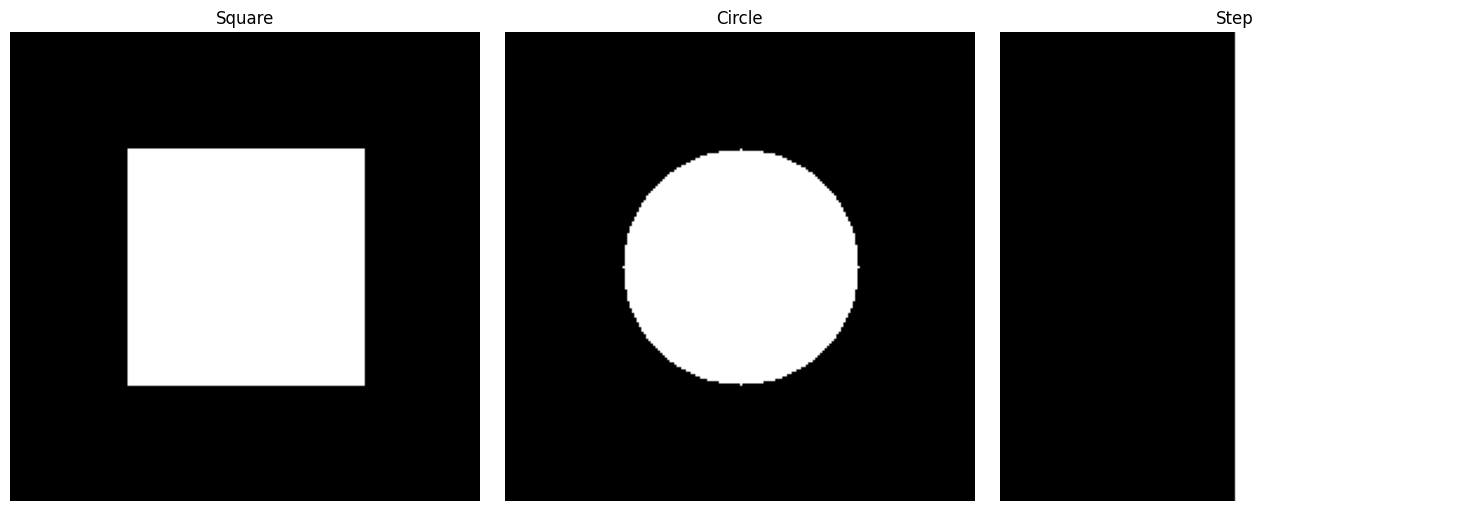

In [6]:
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

img_step[:, :100] = 50
img_step[:, 100:] = 220

show_collection([img_square, img_circle, img_step], ["Square", "Circle", "Step"])

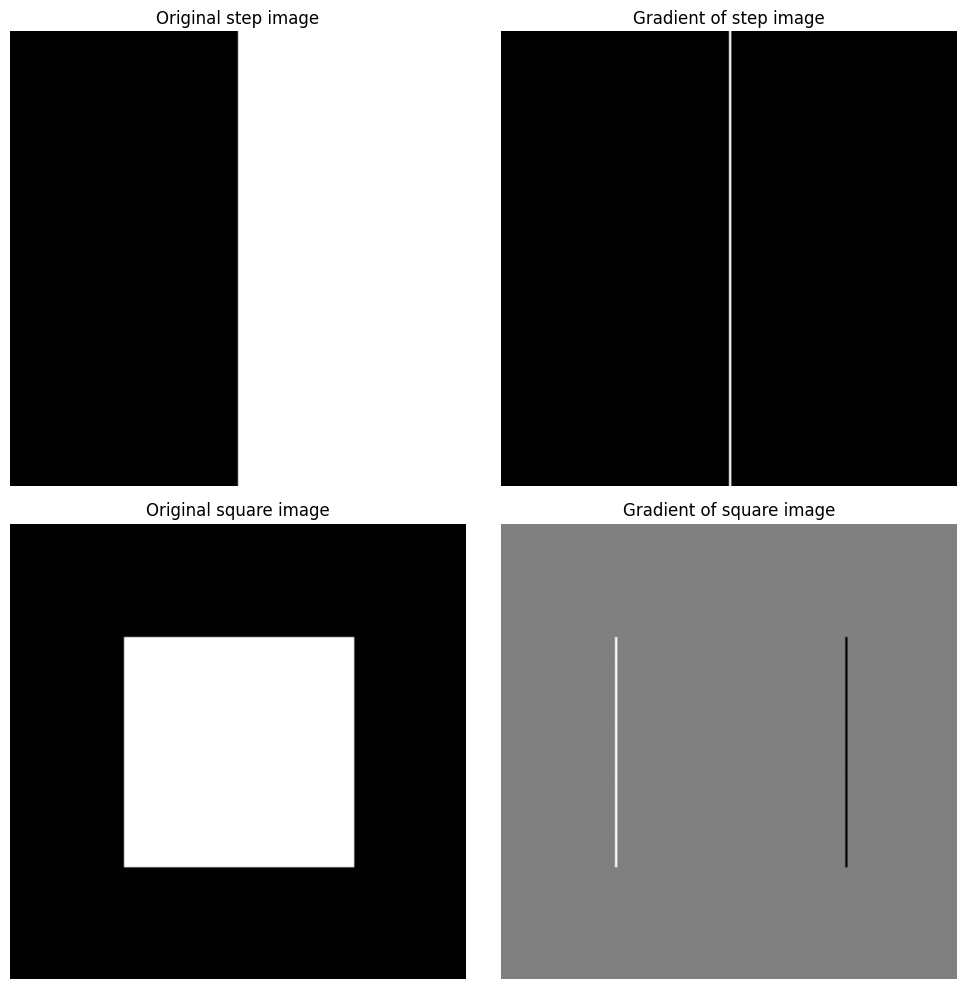

In [7]:
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show_collection([img_step, grad_step, img_square, grad_square], ["Original step image", "Gradient of step image", "Original square image",
                                                                 "Gradient of square image"], cols=2)

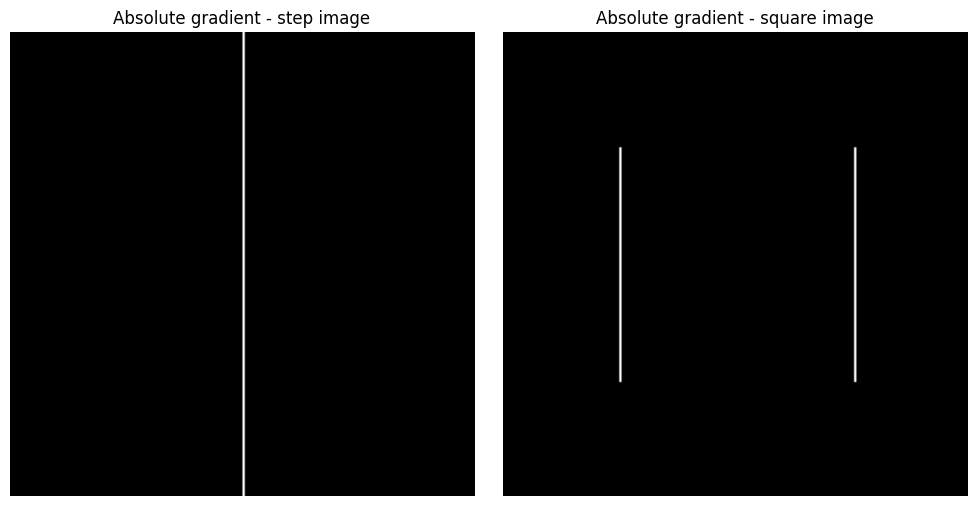

In [8]:
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show_collection(
    images=[grad_step_abs, grad_square_abs], 
    titles=["Absolute gradient - step image", "Absolute gradient - square image"],
    cols=2
)

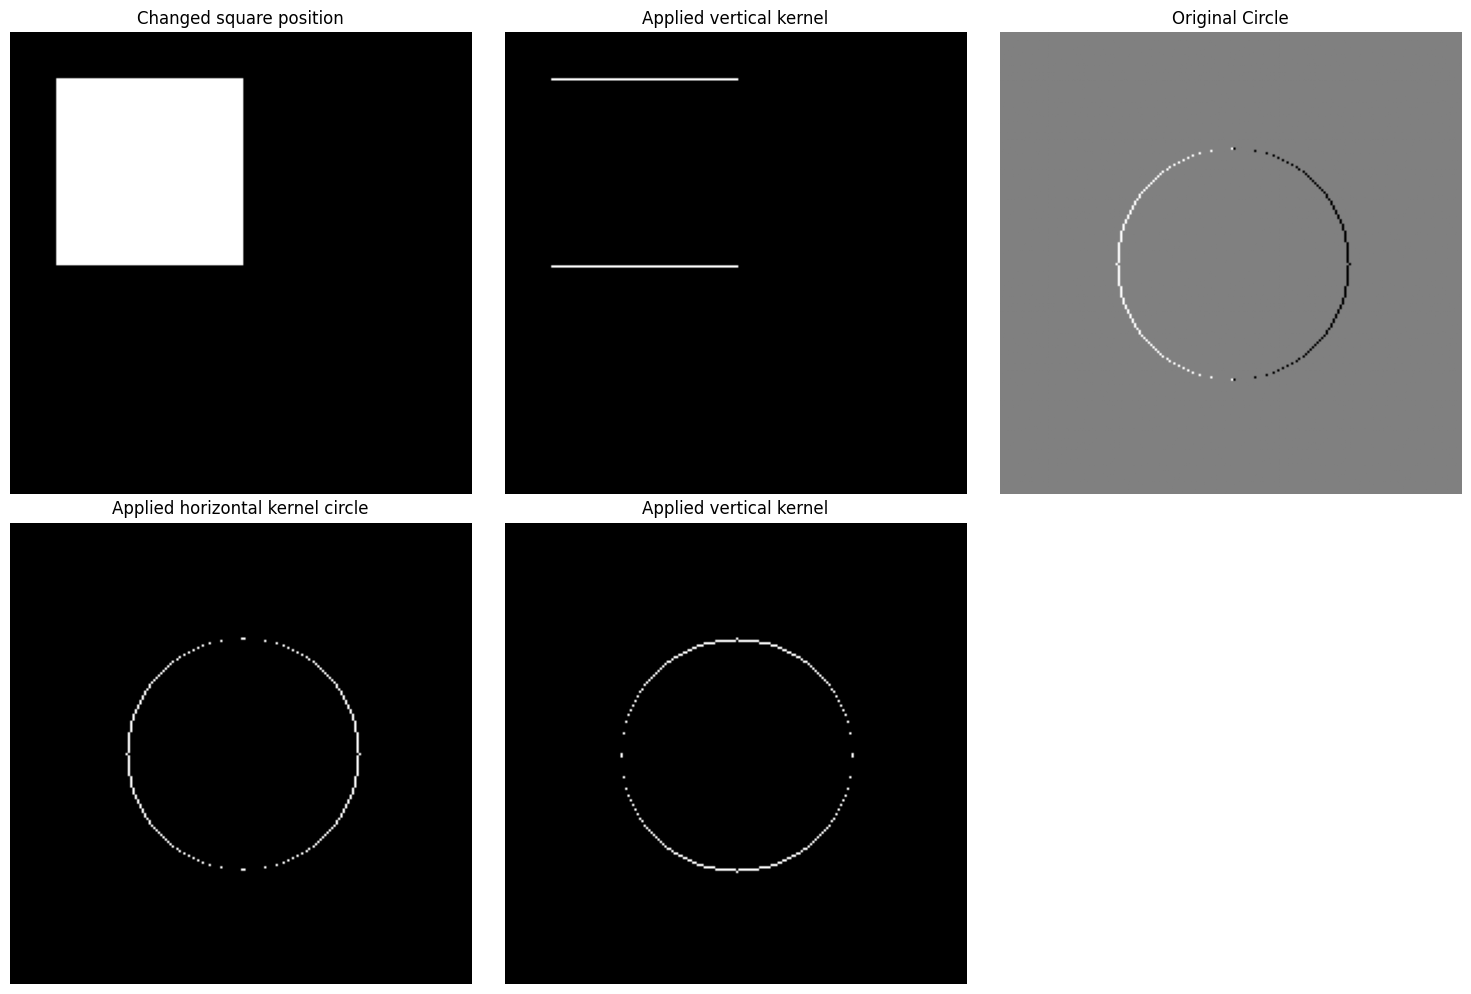

In [11]:
"""Topic 1 Tasks: Gradient with vertical and horizontal kernels"""

# Rectangle
img_square = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_square, (20, 20), (100, 100), 255, -1)

# Circle
img_circle = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

kernel_v = np.array([[-1], [1]], dtype=np.float32) # Vertical kernel
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_v)
grad_square_abs = np.abs(grad_square).astype(np.uint8)

kernel_h = np.array([[-1, 1]], dtype=np.float32) # Horizontal kernel
grad_circle = cv2.filter2D(img_circle, cv2.CV_64F, kernel_h)
grad_circle_abs = np.abs(grad_circle).astype(np.uint8)

kernel_v_circle = np.array([[-1], [1]], dtype=np.float32) # Vertical kernel
grad_v_circle = cv2.filter2D(img_circle, cv2.CV_64F, kernel_v_circle)
grad_v_circle_abs = np.abs(grad_v_circle).astype(np.uint8)

show_collection([img_square, grad_square_abs, grad_circle, grad_circle_abs, grad_v_circle_abs], ["Changed square position",
                                                                               "Applied vertical kernel",
                                                                               "Original Circle",
                                                                               "Applied horizontal kernel circle",
                                                                               "Applied vertical kernel"],
                                                                                cols=3)

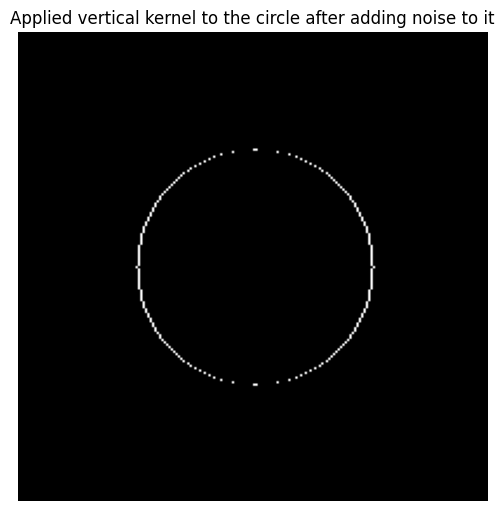

In [13]:
noise = np.random.normal(0, 25, img_square.shape).astype(np.int16)
noisy_square = np.clip(img_square.astype(np.int16) + noise, 0, 255).astype(np.uint8)

kernel_v = np.array([[-1], [1]], dtype=np.float32) # Vertical kernel
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_v)
grad_square_abs = np.abs(grad_square).astype(np.uint8)

show_collection([grad_circle_abs], ["Applied vertical kernel to the circle after adding noise to it"])

In [14]:
def simple_gradient(image, direction='x'):

    if direction == 'x':
        kernel = np.array([[-1, 1]], dtype=np.float32)
    elif direction == 'y':
        kernel = np.array([[-1], [1]], dtype=np.float32)
    else:
        raise ValueError("Direction must be x or y")
    
    return cv2.filter2D(image, cv2.CV_64F, kernel)

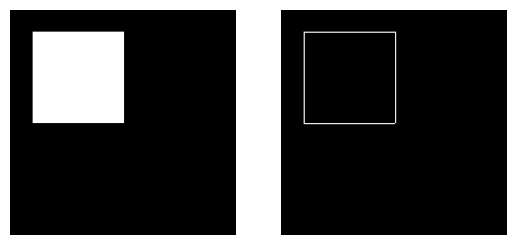

In [21]:

gx = simple_gradient(img_square, 'x')
gy = simple_gradient(img_square, 'y')

magnitude = np.sqrt(gx**2 + gy**2)
mag_uint8 = np.uint8(np.clip(magnitude, 0, 255))

plt.subplot(1, 2, 1); plt.imshow(img_square, cmap="grey"); plt.axis('off');
plt.subplot(1, 2, 2); plt.imshow(mag_uint8, cmap="grey"); plt.axis('off')
plt.show();